# Feature and Model Selection

In [1]:
import warnings
import joblib
from pathlib import Path
import shutil

import numpy as np
import pandas as pd


import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


## Load / Reload Selection Utility Functions

In [2]:
from utils2 import selection as sel

----

## Read Config File

In [3]:
config_path = Path(r'experiments')

# choose between final and development config file
# config_filename = "bin_sel_dev.yml" # development
config_filename = "bin_sel_final.yml" # final

config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict

{'experiment': {'summary': 'binary classification - feature  and model selection (final experiment)',
  'classification_type': 'binary',
  'stage': 'selection',
  'tag': 'final',
  'verbosity': 0,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'feature_selection': {'cross_validation': {'k_splits': 4,
   'n_repeats': 10,
   'scoring': 'youden'},
  'vif_threshold': 5},
 'figures': {'summary_metric': 'youden', 'summary_table_topk': 5}}

#### Set output directory

In [4]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\selection\final


#### Copy config file to output directory

In [5]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/selection/final/bin_sel_final.yml')

## Data Loading

In [6]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type);
D.df.tail(3)

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
187,1,36.0,0,1.0,1.0,6.18,1,0,0,1,0,0,1,0,1,3.0,11.45,49.2,13.79,40.2,41.8,3.60,11.94,8.78,50.3,14.11,43.1,14.95,41.2,42.2,3.7,9.43,7.19,49.9,69.0,4.0,56.0,8.0,83.0,7.0,0
188,0,60.0,1,5.0,1.0,12.20,1,0,1,0,0,1,1,1,1,8.0,5.03,37.9,0.00,0.0,36.3,4.85,5.05,3.06,53.1,5.58,37.2,0.00,0.0,32.2,4.2,5.09,3.28,53.5,16.0,11.0,21.0,9.0,46.0,32.0,1
189,0,65.0,1,15.0,1.0,7.59,1,1,0,1,0,1,1,1,1,8.0,0.00,0.0,0.00,0.0,43.2,5.80,0.56,0.20,0.0,0.00,0.0,0.00,0.0,48.1,5.7,0.27,0.11,0.0,39.0,16.0,41.0,23.0,43.0,44.0,1


Binary Classification Classes:  ['Negative', 'Possible', 'Probable'] vs 'Confirmed'


In [7]:
dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
len(data_cols), data_cols

(40,
 Index(['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD',
        'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR',
        'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L',
        'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R',
        'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R',
        'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM',
        'NS', 'CAS'],
       dtype='object'))

### Data Inspection

In [8]:
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

In [9]:
# get number of postive and negative class
print('Confirmed - positive class', y.sum())
print('Non-confirmed - negative class', y.shape[0]-y.sum())

Confirmed - positive class 130
Non-confirmed - negative class 60


----

## Global Variables

In [10]:
model_metrics = {} # key: experiment code, value: {model: <string> (e.g. all, ncs), rcv_cores: <Dataframe> Perfomance metrics of repeated k-fold of algorithms}
metrics_stats = {} # key: experiment code, value: {stat: <string> (e.g. mean, std), stat (mean/std) of the performance of all algorithms}
youden_scores = {} # key: experiment code, value: list of youden cv scores algorithms
rocauc_scores = {} # key: experiment code, value: list of roc-auc cv scores algorithms

## Iterative Group Feature Elimination

----

### All Features

In [11]:
model_metrics['All'] = sel.benchmark_models(X, y, config) 

100%|██████████| 16/16 [02:20<00:00,  8.81s/it]


In [12]:
model_metrics['All'] # list of dictionary with 2 keys, model and scores (a dataframe)

[{'model': 'Naive',
  'rcv_scores':     accuracy  precision  sensitivity  specificity  youden     f1  roc-auc
  0      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  1      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  2      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  3      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  4      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  5      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  6      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  7      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  8      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  9      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  10     0.681      0.681          1.0          0.0     0.0  0.810      0.5
  11     0.681      0.681          1.0          0.0   

In [13]:
model_metrics.keys() # only experiment named 'All'  loaded so far 

dict_keys(['All'])

In [14]:
len(model_metrics['All']) # number of algorithms

16

In [15]:
model_metrics['All'][0]['model'] # Get model name of algo 0

'Naive'

In [16]:
# get scores for algo 1 (Logistic Regression)   
# expect k*N_REPEATS rows (e.g. 10 for k=5, NREPEATS=2)

model_metrics['All'][1]['rcv_scores'] 

,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
0,0.917,0.968,0.909,0.933,0.842,0.938,0.968
1,0.854,0.882,0.909,0.733,0.642,0.896,0.911
2,0.872,0.906,0.906,0.800,0.706,0.906,0.885
3,0.787,0.824,0.875,0.600,0.475,0.848,0.900
4,0.812,0.875,0.848,0.733,0.582,0.862,0.891
5,0.854,0.861,0.939,0.667,0.606,0.899,0.917
6,0.915,0.938,0.938,0.867,0.804,0.938,0.963
7,0.830,0.853,0.906,0.667,0.573,0.879,0.902
8,0.854,0.882,0.909,0.733,0.642,0.896,0.925
9,0.750,0.862,0.758,0.733,0.491,0.806,0.832


In [17]:
metrics_stats['All'] = sel.calculate_metric_statistics(model_metrics['All'], config)

In [18]:
metrics_stats['All']['std']

,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Naive,0.003,0.003,0.000,0.000,0.000,0.002,0.000
Logistic Regression,0.045,0.034,0.058,0.083,0.096,0.035,0.032
LDA,0.050,0.040,0.055,0.094,0.114,0.038,0.044
QDA,0.050,0.042,0.089,0.181,0.140,0.039,0.053
SGDClassifier,0.063,0.069,0.119,0.196,0.151,0.057,0.041
Decision Tree,0.046,0.044,0.057,0.110,0.112,0.035,0.056
Random Forest,0.031,0.033,0.033,0.078,0.081,0.023,0.017
Extra Trees,0.037,0.040,0.033,0.095,0.099,0.026,0.020
Gradient Boosting,0.040,0.046,0.044,0.115,0.110,0.028,0.028
XGBoost,0.036,0.037,0.037,0.086,0.092,0.026,0.021


#### Get youden and roc-auc scores

In [19]:
youden_scores['All'] = sel.get_metric_scores(model_metrics, 'All', metrics_stats, 'youden')
rocauc_scores['All'] = sel.get_metric_scores(model_metrics, 'All', metrics_stats, 'roc-auc')
rocauc_scores['All']

,CatBoost,Random Forest,XGBoost,Extra Trees,LightGBM,Gradient Boosting,RBF SVM,Decision Tree,Logistic Regression,Naive Bayes,Linear SVM,SGDClassifier,LDA,kNN,QDA,Naive
0,0.982,0.984,0.982,0.984,0.980,0.970,0.970,0.921,0.968,0.994,0.970,0.949,0.960,0.896,0.679,0.5
1,0.988,0.982,0.970,0.995,0.968,0.984,0.974,0.752,0.911,0.931,0.871,0.949,0.857,0.848,0.683,0.5
2,0.963,0.969,0.948,0.971,0.960,0.935,0.879,0.835,0.885,0.878,0.871,0.867,0.858,0.878,0.681,0.5
3,0.963,0.965,0.944,0.942,0.954,0.958,0.927,0.838,0.900,0.906,0.906,0.938,0.890,0.800,0.729,0.5
4,0.954,0.963,0.945,0.943,0.931,0.980,0.913,0.788,0.891,0.878,0.867,0.903,0.889,0.868,0.675,0.5
5,0.964,0.963,0.966,0.959,0.960,0.978,0.907,0.885,0.917,0.867,0.911,0.919,0.901,0.732,0.689,0.5
6,0.983,0.984,0.977,0.996,0.975,0.969,0.981,0.824,0.963,1.000,0.977,0.950,0.881,0.895,0.746,0.5
7,1.000,1.000,1.000,0.994,0.990,0.965,0.967,0.938,0.902,0.954,0.879,0.967,0.829,0.863,0.640,0.5
8,0.968,0.973,0.947,0.958,0.968,0.964,0.945,0.855,0.925,0.954,0.949,0.945,0.905,0.843,0.752,0.5
9,0.943,0.935,0.958,0.929,0.919,0.929,0.873,0.791,0.832,0.867,0.776,0.824,0.794,0.751,0.709,0.5


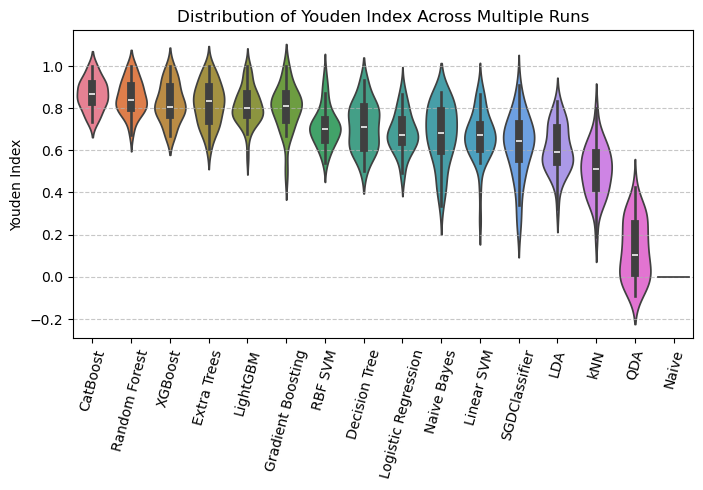

In [20]:
sel.plot_metric_scores(youden_scores, config, exp_code='All', savedir=outputdir)

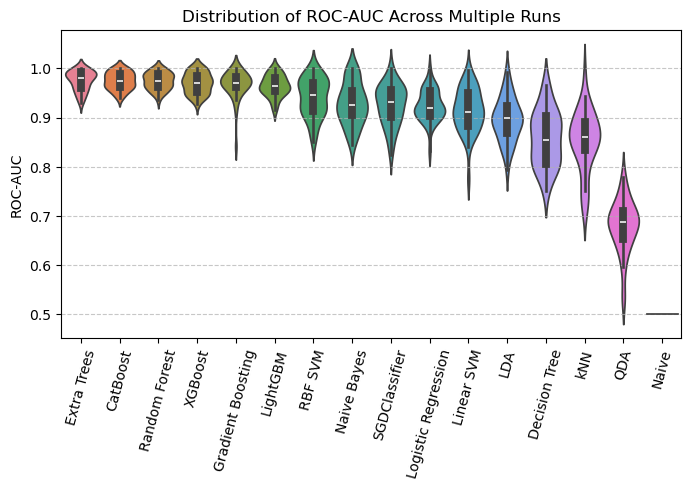

In [21]:
sel.plot_metric_scores(rocauc_scores, config, exp_code='All', 
                       target_metric='roc-auc',savedir=outputdir)

### No Collinear Features

In [22]:
high_vif = sel.get_high_vif(X, config)

In [23]:
# drop these features which seem to be collinear
high_vif_features = high_vif.feature.values.tolist()[1:]
print(high_vif_features)

['SSA_L', 'SSC_L', 'SPSC_L', 'CMAPANK_L', 'CMAPKNE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'CMAPANK_R', 'CMAPKNE_R']


In [24]:
Xnc = X.drop(columns=high_vif_features) #X no collinear
print(Xnc.shape) 
Xnc.head(2)

(190, 29)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SPSA_L,MCV_L,DL_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,20.7,10.35,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,4.0,14.21,49.3,3.55,42.5,48.3,3.30,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [25]:
model_metrics['NoCol'] = sel.benchmark_models(Xnc, y, config, verbosity=0)
metrics_stats['NoCol'] = sel.calculate_metric_statistics(model_metrics['NoCol'], config)
metrics_stats['NoCol']['mean']

100%|██████████| 16/16 [01:21<00:00,  5.08s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Random Forest,0.844,0.867,0.916,0.688,0.604,0.890,0.910
CatBoost,0.835,0.859,0.912,0.668,0.581,0.884,0.911
LightGBM,0.825,0.865,0.885,0.695,0.580,0.874,0.896
XGBoost,0.826,0.858,0.896,0.673,0.569,0.876,0.899
Gradient Boosting,0.822,0.859,0.888,0.677,0.565,0.872,0.898
Extra Trees,0.820,0.845,0.905,0.637,0.541,0.873,0.884
Logistic Regression,0.802,0.845,0.872,0.650,0.522,0.857,0.863
LDA,0.784,0.840,0.846,0.650,0.496,0.842,0.855
Naive Bayes,0.730,0.887,0.703,0.788,0.491,0.760,0.868
Linear SVM,0.780,0.838,0.843,0.642,0.485,0.839,0.838


 -----

### No NCS

In [26]:
Xnncs = X.drop(columns=D.ncs_cols) #X no nerve conduction studies
print(D.ncs_cols)
Xnncs.shape, Xnncs.head(2)

['SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R']


((190, 22),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  MNSI  FEET_MEAN_ESC  FEET_PCT_ASYM  \
 0       1        1        1       1   9.0           12.0            0.0   
 1       0        0        0       0   4.0           39.0            5.0   
 
    HAND_MEAN_ESC  HAND_PCT_ASYM    NS   CAS  
 0           33.0           13.0  42.0  34.0  
 1           38.0           28.0  50.0  39.0  )

In [27]:
model_metrics['NoCS'] = sel.benchmark_models(Xnncs, y, config, verbosity=0)
metrics_stats['NoCS'] = sel.calculate_metric_statistics(model_metrics['NoCS'], config)
metrics_stats['NoCS']['mean']

100%|██████████| 16/16 [01:17<00:00,  4.83s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Random Forest,0.806,0.826,0.911,0.580,0.491,0.865,0.818
CatBoost,0.803,0.821,0.912,0.567,0.479,0.864,0.817
LDA,0.776,0.832,0.845,0.627,0.472,0.837,0.800
Logistic Regression,0.782,0.821,0.874,0.582,0.456,0.845,0.792
RBF SVM,0.801,0.804,0.939,0.500,0.439,0.866,0.824
Gradient Boosting,0.766,0.810,0.862,0.558,0.420,0.833,0.764
Linear SVM,0.761,0.812,0.849,0.570,0.419,0.828,0.775
Extra Trees,0.770,0.806,0.876,0.538,0.415,0.838,0.807
XGBoost,0.759,0.809,0.849,0.563,0.412,0.827,0.772
LightGBM,0.755,0.805,0.849,0.553,0.402,0.825,0.765


 -----

### No Sudoscan Features

In [28]:
Xnsudo = X.drop(columns=D.sudo_cols) #X no nerve conduction studies
print(D.sudo_cols)
print(Xnsudo.shape)
Xnsudo.head(2)

['FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'NS', 'CAS']
(190, 34)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3


In [29]:
model_metrics['NoSudo'] = sel.benchmark_models(Xnsudo, y, config, verbosity=0)
metrics_stats['NoSudo'] = sel.calculate_metric_statistics(model_metrics['NoSudo'], config)
metrics_stats['NoSudo']['mean']

100%|██████████| 16/16 [01:51<00:00,  6.99s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.946,0.962,0.960,0.917,0.877,0.961,0.974
Random Forest,0.940,0.955,0.959,0.898,0.858,0.956,0.970
XGBoost,0.929,0.945,0.952,0.877,0.829,0.948,0.966
Extra Trees,0.926,0.941,0.952,0.868,0.821,0.946,0.974
LightGBM,0.923,0.940,0.949,0.867,0.816,0.944,0.965
Gradient Boosting,0.913,0.931,0.945,0.843,0.789,0.937,0.959
RBF SVM,0.910,0.927,0.945,0.835,0.780,0.935,0.949
Decision Tree,0.884,0.920,0.915,0.818,0.733,0.915,0.866
Logistic Regression,0.887,0.914,0.924,0.808,0.732,0.918,0.935
Linear SVM,0.870,0.903,0.909,0.783,0.693,0.905,0.926


 -----

### No Neuro Features

In [30]:
Xnneuro = X.drop(columns=D.neuro_cols) #X no neuro columns
print(D.neuro_cols)
print(Xnneuro.shape) 
Xnneuro.head(2)

['DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR']
(190, 36)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [31]:
model_metrics['NoNeuro'] = sel.benchmark_models(Xnneuro, y, config,verbosity=0)
metrics_stats['NoNeuro'] = sel.calculate_metric_statistics(model_metrics['NoNeuro'], config)
metrics_stats['NoNeuro']['mean']

100%|██████████| 16/16 [01:45<00:00,  6.58s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.945,0.960,0.961,0.910,0.871,0.960,0.974
Random Forest,0.940,0.952,0.961,0.893,0.854,0.956,0.973
Extra Trees,0.933,0.949,0.955,0.887,0.841,0.951,0.974
XGBoost,0.925,0.940,0.954,0.863,0.817,0.946,0.969
Gradient Boosting,0.927,0.936,0.961,0.853,0.814,0.947,0.966
LightGBM,0.922,0.939,0.949,0.865,0.814,0.943,0.965
RBF SVM,0.890,0.905,0.939,0.782,0.721,0.921,0.941
Decision Tree,0.873,0.911,0.905,0.802,0.707,0.907,0.854
Logistic Regression,0.868,0.901,0.909,0.780,0.689,0.903,0.927
Linear SVM,0.863,0.904,0.898,0.788,0.686,0.899,0.916


 -----

### No Commorbidity Features

In [32]:
Xncom = X.drop(columns=D.comorbidity_cols) #X no neuro columns
print(D.comorbidity_cols)
print(Xncom.shape)
Xncom.head(2)

['HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS']
(190, 35)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [33]:
model_metrics['NoCom'] = sel.benchmark_models(Xncom, y, config, verbosity=0)
metrics_stats['NoCom'] = sel.calculate_metric_statistics(model_metrics['NoCom'], config)
metrics_stats['NoCom']['mean']

100%|██████████| 16/16 [01:44<00:00,  6.56s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.944,0.959,0.960,0.908,0.868,0.959,0.975
Random Forest,0.940,0.953,0.961,0.895,0.856,0.956,0.973
XGBoost,0.928,0.943,0.955,0.872,0.826,0.948,0.971
LightGBM,0.923,0.940,0.949,0.865,0.814,0.944,0.966
Extra Trees,0.919,0.937,0.946,0.858,0.805,0.941,0.975
Gradient Boosting,0.919,0.933,0.954,0.845,0.799,0.942,0.968
Naive Bayes,0.835,0.974,0.780,0.955,0.735,0.865,0.949
Decision Tree,0.879,0.916,0.910,0.812,0.722,0.911,0.861
RBF SVM,0.887,0.904,0.936,0.780,0.716,0.919,0.942
Logistic Regression,0.873,0.907,0.909,0.793,0.703,0.907,0.930


 -----

### No MNSI Feature

In [34]:
Xnmnsi = X.drop(columns=D.mnsi_col) #X no neuro columns
print(D.mnsi_col)
print(Xnmnsi.shape)
Xnmnsi.head(2)

['MNSI']
(190, 39)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [35]:
model_metrics['NoMSI'] = sel.benchmark_models(Xnmnsi, y, config, verbosity=0)
metrics_stats['NoMSI'] = sel.calculate_metric_statistics(model_metrics['NoMSI'], config)
metrics_stats['NoMSI']['mean']

100%|██████████| 16/16 [01:46<00:00,  6.67s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.943,0.958,0.960,0.907,0.867,0.959,0.974
Random Forest,0.938,0.951,0.961,0.890,0.851,0.955,0.970
Extra Trees,0.924,0.942,0.949,0.870,0.819,0.945,0.975
XGBoost,0.926,0.940,0.955,0.863,0.819,0.947,0.968
LightGBM,0.922,0.941,0.947,0.868,0.815,0.943,0.963
Gradient Boosting,0.921,0.937,0.950,0.858,0.808,0.943,0.968
RBF SVM,0.889,0.903,0.941,0.777,0.718,0.921,0.940
Decision Tree,0.879,0.912,0.915,0.802,0.716,0.911,0.858
Logistic Regression,0.870,0.901,0.911,0.780,0.691,0.905,0.928
Naive Bayes,0.808,0.956,0.754,0.927,0.680,0.838,0.929


 -----

### No Profile Feature

In [36]:
Xnprof = X.drop(columns=D.profile_cols) #X no neuro columns
print(D.profile_cols)
print(Xnprof.shape) 
Xnprof.head(2)

['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C']
(190, 34)


,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,1,0,0,0,0,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [37]:
model_metrics['NoProf'] = sel.benchmark_models(Xnprof, y, config, verbosity=0)
metrics_stats['NoProf'] = sel.calculate_metric_statistics(model_metrics['NoProf'], config)
metrics_stats['NoProf']['mean']

100%|██████████| 16/16 [01:57<00:00,  7.37s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.940,0.957,0.956,0.905,0.861,0.956,0.967
Random Forest,0.937,0.953,0.957,0.893,0.850,0.954,0.967
Extra Trees,0.920,0.940,0.944,0.867,0.811,0.942,0.964
XGBoost,0.918,0.936,0.946,0.857,0.803,0.940,0.959
LightGBM,0.915,0.938,0.940,0.862,0.802,0.938,0.954
Gradient Boosting,0.916,0.931,0.950,0.842,0.792,0.939,0.963
RBF SVM,0.889,0.908,0.934,0.790,0.724,0.920,0.938
Decision Tree,0.879,0.916,0.910,0.813,0.723,0.911,0.862
Logistic Regression,0.869,0.902,0.908,0.783,0.691,0.904,0.922
Linear SVM,0.855,0.903,0.884,0.792,0.676,0.892,0.913


 -----

### NCS Only

In [38]:
Xncs = X[D.ncs_cols] #X nerve conduction studies
print(D.ncs_cols)
print(Xncs.shape) 
Xncs.head(2)

['SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R']
(190, 18)


,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R
0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0
1,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3


In [39]:
model_metrics['NCS'] = sel.benchmark_models(Xncs, y, config, verbosity=0)
metrics_stats['NCS'] = sel.calculate_metric_statistics(model_metrics['NCS'], config)
metrics_stats['NCS']['mean']

100%|██████████| 16/16 [01:49<00:00,  6.83s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.941,0.958,0.957,0.907,0.864,0.957,0.946
Extra Trees,0.938,0.959,0.951,0.910,0.861,0.954,0.950
Random Forest,0.937,0.951,0.959,0.890,0.849,0.954,0.945
kNN,0.921,0.949,0.936,0.887,0.823,0.942,0.936
RBF SVM,0.924,0.941,0.949,0.868,0.818,0.944,0.933
Linear SVM,0.909,0.953,0.913,0.900,0.813,0.932,0.936
Gradient Boosting,0.921,0.938,0.949,0.862,0.810,0.943,0.935
XGBoost,0.917,0.936,0.946,0.857,0.802,0.940,0.924
LightGBM,0.914,0.933,0.943,0.850,0.793,0.937,0.931
Logistic Regression,0.907,0.938,0.926,0.865,0.791,0.931,0.938


### Sudoscan Only Only

In [40]:
Xsudo = X[D.sudo_cols] 
print(Xsudo.shape) 
Xsudo.head(2)

(190, 6)


,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,12.0,0.0,33.0,13.0,42.0,34.0
1,39.0,5.0,38.0,28.0,50.0,39.0


In [41]:
model_metrics['Sudo'] = sel.benchmark_models(Xsudo, y, config, verbosity=0)
metrics_stats['Sudo'] = sel.calculate_metric_statistics(model_metrics['Sudo'], config)
metrics_stats['Sudo']['mean']

100%|██████████| 16/16 [01:37<00:00,  6.10s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Naive Bayes,0.734,0.775,0.865,0.452,0.316,0.816,0.720
Random Forest,0.725,0.766,0.863,0.427,0.290,0.811,0.701
Extra Trees,0.724,0.763,0.867,0.415,0.282,0.811,0.685
CatBoost,0.731,0.758,0.891,0.383,0.275,0.819,0.700
Linear SVM,0.739,0.756,0.915,0.358,0.273,0.827,0.711
LDA,0.732,0.757,0.897,0.373,0.270,0.820,0.696
Logistic Regression,0.734,0.753,0.912,0.348,0.261,0.824,0.695
LightGBM,0.699,0.760,0.818,0.442,0.259,0.786,0.646
Gradient Boosting,0.696,0.760,0.813,0.442,0.255,0.784,0.683
XGBoost,0.681,0.749,0.803,0.415,0.218,0.773,0.646


## Summary of Iterative Group Feature Elimination

In [42]:
model_metrics.keys(), metrics_stats.keys()

(dict_keys(['All', 'NoCol', 'NoCS', 'NoSudo', 'NoNeuro', 'NoCom', 'NoMSI', 'NoProf', 'NCS', 'Sudo']),
 dict_keys(['All', 'NoCol', 'NoCS', 'NoSudo', 'NoNeuro', 'NoCom', 'NoMSI', 'NoProf', 'NCS', 'Sudo']))

In [43]:
summary_metric = config.figures.summary_metric
summary_topk = config.figures.summary_table_topk

In [44]:
from utils2 import selection as sel

youden 5 target_metric, topk,


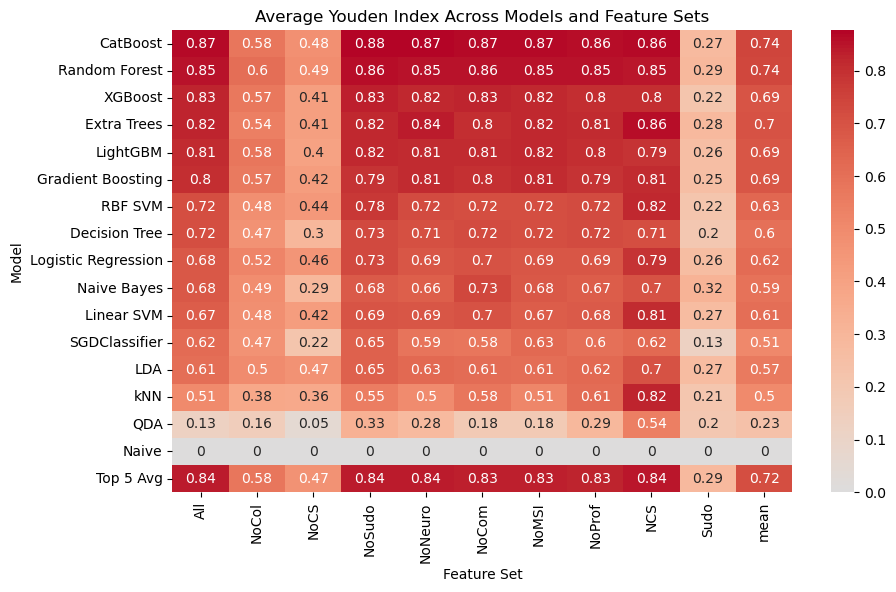

In [45]:
# Summary: including all columns and stats
sel.create_model_summary_table(metrics_stats, config,
                           exclude_features=[],
                           include_mean=True, 
                           show_plot=True,
                           savedir=outputdir);

In [46]:
# Summary: clean table without mean, topk
sel.create_model_summary_table(metrics_stats, config,
                           topk=0, 
                           exclude_features=[],
                           include_mean=False, 
                           show_plot=False,
                           savedir=outputdir);                           


youden 0 target_metric, topk,


roc-auc 5 target_metric, topk,


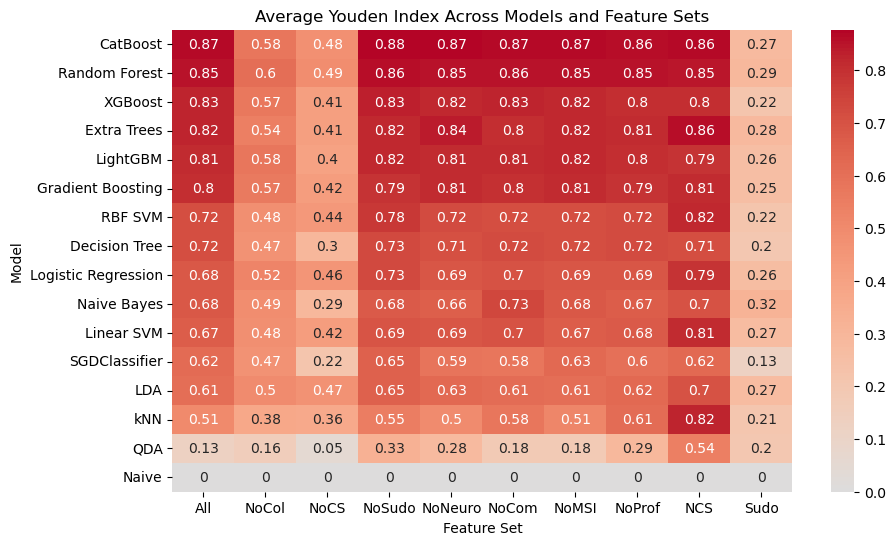

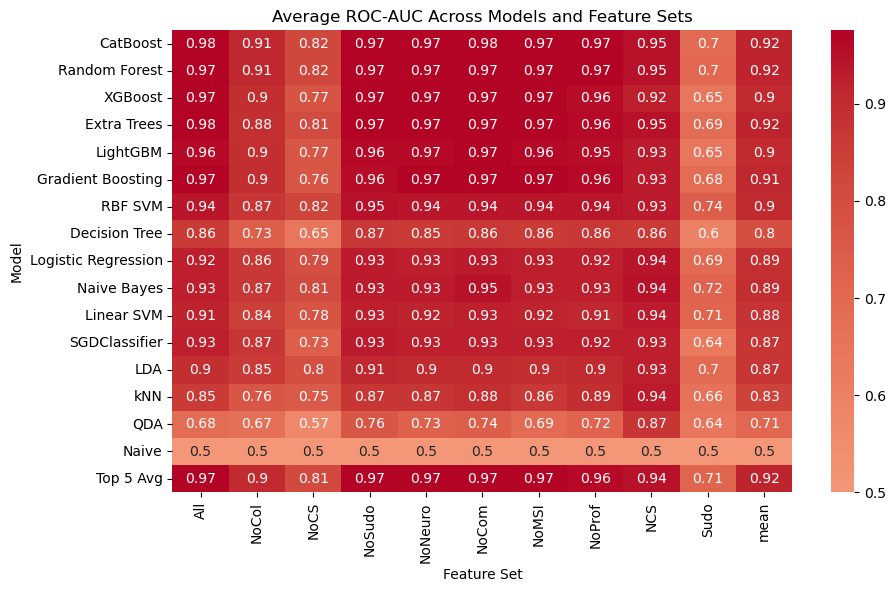

In [47]:
# ROC-AUC Summary: including all columns and stats
sel.create_model_summary_table(metrics_stats, config, 
                           target_metric='roc-auc', 
                           exclude_features=[],
                           include_mean=True, 
                           show_plot=True,
                           savedir=outputdir);    

In [48]:
# ROC-AUC Summary: clean table without mean, topk
sel.create_model_summary_table(metrics_stats, config,
                           target_metric='roc-auc', 
                           topk=0, 
                           exclude_features=[],
                           include_mean=False, 
                           show_plot=False,
                           savedir=outputdir);

roc-auc 0 target_metric, topk,


 -----

## Save the Metrics to json 

In [49]:
joblib.dump(model_metrics, outputdir / "model_metrics.joblib");
joblib.dump(metrics_stats, outputdir / "metrics_stats.joblib");
joblib.dump(youden_scores, outputdir / "youden_scores.joblib");
joblib.dump(rocauc_scores, outputdir / "rocauc_scores.joblib");

 -----

## Load Save Results and Verify

In [50]:
# Verify saved results
loaded_model_metrics = joblib.load(outputdir / "model_metrics.joblib")
sel.calculate_metric_statistics(loaded_model_metrics['All'], config)

{'mean':                      accuracy  precision  sensitivity  specificity  youden  \
 CatBoost                0.943      0.958        0.960        0.907   0.867   
 Random Forest           0.940      0.952        0.962        0.892   0.853   
 XGBoost                 0.929      0.943        0.955        0.872   0.827   
 Extra Trees             0.927      0.941        0.955        0.867   0.822   
 LightGBM                0.922      0.939        0.948        0.865   0.813   
 Gradient Boosting       0.920      0.934        0.954        0.848   0.802   
 RBF SVM                 0.886      0.904        0.936        0.780   0.716   
 Decision Tree           0.878      0.912        0.912        0.803   0.715   
 Logistic Regression     0.866      0.899        0.908        0.777   0.684   
 Naive Bayes             0.807      0.956        0.752        0.927   0.679   
 Linear SVM              0.855      0.898        0.889        0.780   0.669   
 SGDClassifier           0.838      0.890   

In [51]:
loaded_metric_stats = joblib.load(outputdir / "metrics_stats.joblib")
loaded_metric_stats['All']['std']

,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Naive,0.003,0.003,0.000,0.000,0.000,0.002,0.000
Logistic Regression,0.045,0.034,0.058,0.083,0.096,0.035,0.032
LDA,0.050,0.040,0.055,0.094,0.114,0.038,0.044
QDA,0.050,0.042,0.089,0.181,0.140,0.039,0.053
SGDClassifier,0.063,0.069,0.119,0.196,0.151,0.057,0.041
Decision Tree,0.046,0.044,0.057,0.110,0.112,0.035,0.056
Random Forest,0.031,0.033,0.033,0.078,0.081,0.023,0.017
Extra Trees,0.037,0.040,0.033,0.095,0.099,0.026,0.020
Gradient Boosting,0.040,0.046,0.044,0.115,0.110,0.028,0.028
XGBoost,0.036,0.037,0.037,0.086,0.092,0.026,0.021


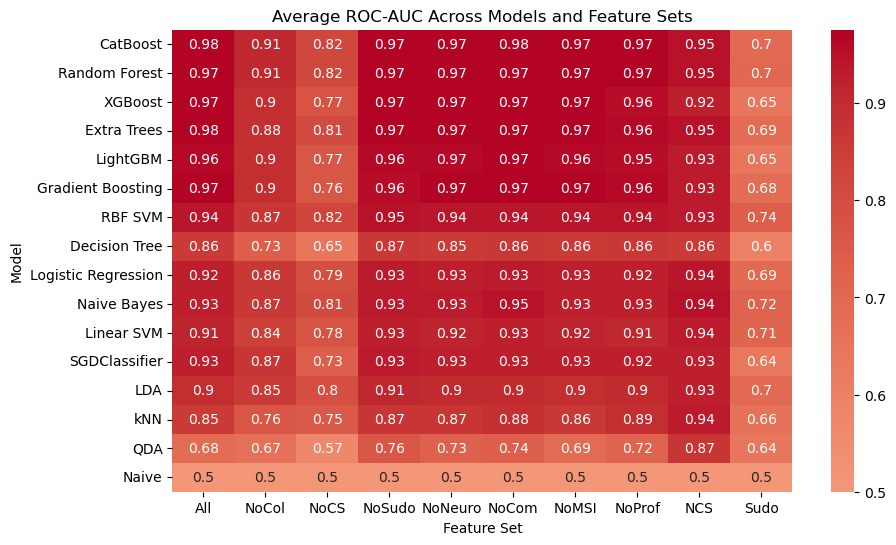

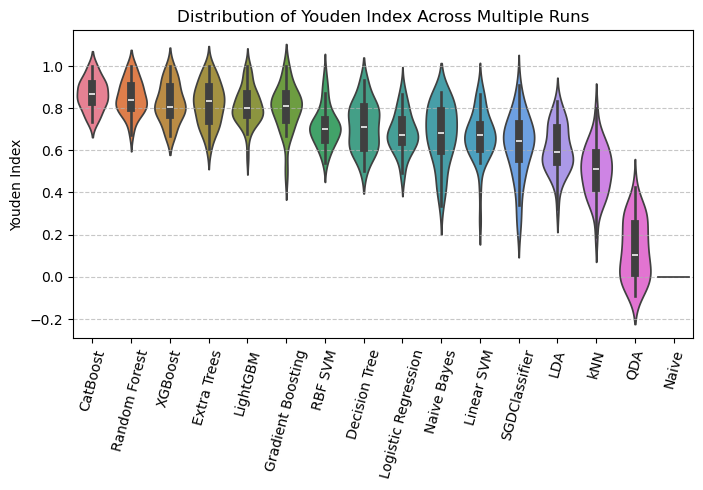

In [52]:
loaded_youden_scores = joblib.load(outputdir / "youden_scores.joblib")
sel.plot_metric_scores(loaded_youden_scores, 
                       config, exp_code='All', 
                       sorted=True, 
                       savedir=None)

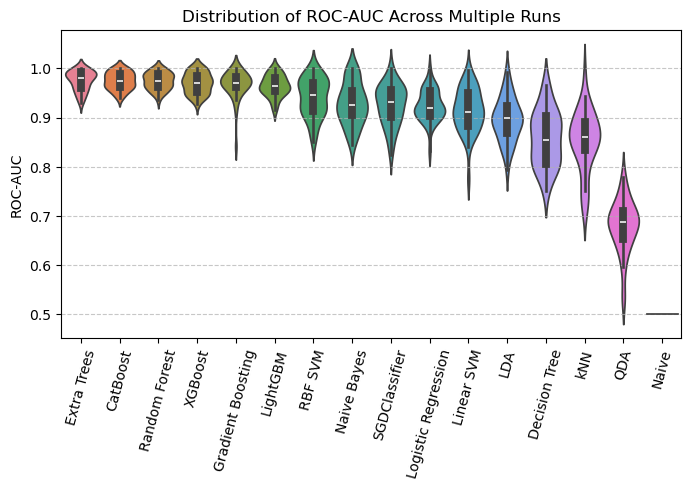

In [53]:
loaded_rocauc_scores = joblib.load(outputdir / "rocauc_scores.joblib")
sel.plot_metric_scores(loaded_rocauc_scores, config, exp_code='All', sorted=True, 
                   target_metric='roc-auc',
                   savedir=None)

 -----